# Notebook 04 — I-JEPA Fine-tuning trên RSNA

**Fixed version** — pos_weight, LR scheduler, tăng epochs, unfreeze 4 blocks, checkpoint cleanup.

In [1]:
# ============================================================
# CELL 1: IMPORT THƯ VIỆN VÀ CẤU HÌNH CHUNG
# ============================================================

import os, gc, json, math, random, shutil, zipfile, time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

# ── Seed ──────────────────────────────────────────────────
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

# ── Device ────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

# ── Output dirs ───────────────────────────────────────────
OUTPUT_DIR = Path("/kaggle/working/notebook04_ijepa_finetune")
CKPT_DIR   = OUTPUT_DIR / "checkpoints"
PRED_DIR   = OUTPUT_DIR / "predictions"
LOG_DIR    = OUTPUT_DIR / "logs"
FIG_DIR    = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, CKPT_DIR, PRED_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output dir:", OUTPUT_DIR)

Device: cuda
GPU: Tesla T4
CUDA: 12.8
Output dir: /kaggle/working/notebook04_ijepa_finetune


In [2]:
# ============================================================
# CELL 2: CÀI / IMPORT TIMM VÀ PYDICOM
# ============================================================

try:
    import timm
except ImportError:
    !pip install -q timm
    import timm

try:
    import pydicom
except ImportError:
    !pip install -q pydicom
    import pydicom

print("timm:", timm.__version__)
print("pydicom: OK")

timm: 1.0.25
pydicom: OK


In [3]:
# ============================================================
# CELL 3: TIME GUARD
# ============================================================

SESSION_SAFE_HOURS   = 11.5
SESSION_SAFE_SECONDS = SESSION_SAFE_HOURS * 3600
NOTEBOOK_START_TIME  = time.time()

print(f"Time guard: {SESSION_SAFE_HOURS}h")

Time guard: 11.5h


In [4]:
# ============================================================
# CELL 4: TÌM METADATA RSNA TỪ NOTEBOOK 01
# ============================================================

INPUT_ROOT   = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")

def find_file(filename):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    return None

RSNA_TRAIN_CSV = find_file("rsna_train.csv")
RSNA_VAL_CSV   = find_file("rsna_val.csv")
RSNA_TEST_CSV  = find_file("rsna_test.csv")

print("RSNA_TRAIN_CSV:", RSNA_TRAIN_CSV)
print("RSNA_VAL_CSV  :", RSNA_VAL_CSV)
print("RSNA_TEST_CSV :", RSNA_TEST_CSV)

assert RSNA_TRAIN_CSV, "Không tìm thấy rsna_train.csv"
assert RSNA_VAL_CSV,   "Không tìm thấy rsna_val.csv"
assert RSNA_TEST_CSV,  "Không tìm thấy rsna_test.csv"

print("Metadata RSNA OK.")

RSNA_TRAIN_CSV: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_train.csv
RSNA_VAL_CSV  : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_val.csv
RSNA_TEST_CSV : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv
Metadata RSNA OK.


In [5]:
# ============================================================
# CELL 5: ĐỌC METADATA RSNA
# ============================================================

train_df = pd.read_csv(RSNA_TRAIN_CSV)
val_df   = pd.read_csv(RSNA_VAL_CSV)
test_df  = pd.read_csv(RSNA_TEST_CSV)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("Train label distribution:")
print(train_df["label"].value_counts())

display(train_df.head(3))

Train: (18678, 4)
Val  : (4003, 4)
Test : (4003, 4)
Train label distribution:
label
0    14470
1     4208
Name: count, dtype: int64


,patientId,label,num_boxes,image_path
0,9b79a98f-a665-42ab-a74f-1fb5bc355247,0,0,/kaggle/input/competitions/rsna-pneumonia-dete...
1,125a6b00-d20c-413e-b5fb-3728fcfce39f,1,1,/kaggle/input/competitions/rsna-pneumonia-dete...
2,e0a6d43d-5889-4d2a-a853-3b3234ac8fbb,0,0,/kaggle/input/competitions/rsna-pneumonia-dete...


In [6]:
# ============================================================
# CELL 6: KIỂM TRA / SỬA ĐƯỜNG DẪN ẢNH RSNA
# ============================================================

def count_missing(df):
    return (~df["image_path"].apply(lambda x: Path(x).exists())).sum()

def find_dir(root, dirname):
    matches = [p for p in Path(root).rglob(dirname) if p.is_dir()]
    return matches[0] if matches else None

print("Missing trước fix - train:", count_missing(train_df),
      "val:", count_missing(val_df), "test:", count_missing(test_df))

if count_missing(train_df) + count_missing(val_df) + count_missing(test_df) > 0:
    RSNA_IMG_DIR = find_dir(INPUT_ROOT, "stage_2_train_images")
    assert RSNA_IMG_DIR, "Không tìm thấy stage_2_train_images — hãy add RSNA dataset."
    print("RSNA_IMG_DIR:", RSNA_IMG_DIR)

    for df in [train_df, val_df, test_df]:
        df["image_path"] = df["patientId"].apply(
            lambda x: str(RSNA_IMG_DIR / f"{x}.dcm")
        )

print("Missing sau fix - train:", count_missing(train_df),
      "val:", count_missing(val_df), "test:", count_missing(test_df))

assert count_missing(train_df) == 0
assert count_missing(val_df)   == 0
assert count_missing(test_df)  == 0

print("Đường dẫn ảnh RSNA OK.")

Missing trước fix - train: 0 val: 0 test: 0
Missing sau fix - train: 0 val: 0 test: 0
Đường dẫn ảnh RSNA OK.


In [7]:
# ============================================================
# CELL 7: TÌM I-JEPA ENCODER CHECKPOINT TỪ NOTEBOOK 03
# ============================================================
# Tự động tìm — không cần nhập tay đường dẫn.
# Chỉ cần đã add output Notebook 03 làm Input Dataset.
# ============================================================

def find_ijepa_encoder():
    patterns = [
        "ijepa_vit_small_nih_50k_best_encoder.pth",
        "ijepa_vit_small_nih_30k_best_encoder.pth",
        "ijepa_vit_small_nih_*_best_encoder.pth",
        "ijepa_vit_small_nih_*_encoder_epoch_*.pth",
    ]
    candidates = []
    for pat in patterns:
        candidates += list(WORKING_ROOT.rglob(pat))
        candidates += list(INPUT_ROOT.rglob(pat))

    # deduplicate
    seen, unique = set(), []
    for p in candidates:
        if str(p) not in seen:
            unique.append(p); seen.add(str(p))
    return unique

candidates = find_ijepa_encoder()
print("Encoder candidates found:")
for i, p in enumerate(candidates):
    print(f"  [{i}] {p}")

assert candidates, (
    "Không tìm thấy I-JEPA encoder checkpoint!"
    "Hãy add output Notebook 03 làm Input Dataset trước khi chạy."
)

# Ưu tiên: 50k best > 30k best > epoch mới nhất
IJEPA_ENCODER_CKPT = None
for p in candidates:
    if "50k_best_encoder" in p.name:
        IJEPA_ENCODER_CKPT = p; break
if IJEPA_ENCODER_CKPT is None:
    for p in candidates:
        if "best_encoder" in p.name:
            IJEPA_ENCODER_CKPT = p; break
if IJEPA_ENCODER_CKPT is None:
    IJEPA_ENCODER_CKPT = candidates[0]

print("Selected:", IJEPA_ENCODER_CKPT)

Encoder candidates found:
  [0] /kaggle/input/notebooks/nguyentongphuc/03-i-jepa-pretraining2/notebook03_ijepa_pretrain/checkpoints/ijepa_vit_small_nih_50k_best_encoder.pth
  [1] /kaggle/input/notebooks/nguyentongphuc/03-i-jepa-pretraining2/notebook03_ijepa_pretrain/checkpoints/ijepa_vit_small_nih_50k_encoder_epoch_49.pth
  [2] /kaggle/input/notebooks/nguyentongphuc/03-i-jepa-pretraining2/notebook03_ijepa_pretrain/checkpoints/ijepa_vit_small_nih_50k_encoder_epoch_50.pth
  [3] /kaggle/input/notebooks/nguyentongphuc/03-i-jepa-pretraining2/notebook03_ijepa_pretrain/checkpoints/ijepa_vit_small_nih_50k_encoder_epoch_48.pth
Selected: /kaggle/input/notebooks/nguyentongphuc/03-i-jepa-pretraining2/notebook03_ijepa_pretrain/checkpoints/ijepa_vit_small_nih_50k_best_encoder.pth


In [8]:
# ============================================================
# CELL 8: HÀM ĐỌC ẢNH DICOM
# ============================================================

def read_dicom_as_pil(path):
    dicom = pydicom.dcmread(path)
    img   = dicom.pixel_array.astype(np.float32)
    img   = img - np.min(img)
    mx    = np.max(img)
    if mx > 0:
        img = img / mx
    img = (img * 255).astype(np.uint8)
    return Image.fromarray(img).convert("RGB")

In [9]:
# ============================================================
# CELL 9: TRANSFORMS
# ============================================================

IMG_SIZE       = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=7),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms ready.")

Transforms ready.


In [10]:
# ============================================================
# CELL 10: DATASET CLASS
# ============================================================

class RSNADataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = read_dicom_as_pil(row["image_path"])
        label = float(row["label"])
        if self.transform:
            image = self.transform(image)
        return {
            "image":     image,
            "label":     torch.tensor(label, dtype=torch.float32),
            "patientId": row["patientId"]
        }

In [11]:
# ============================================================
# CELL 11: DATALOADER + POS_WEIGHT (class imbalance fix)
# ============================================================

BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = RSNADataset(train_df, transform=train_transform)
val_dataset   = RSNADataset(val_df,   transform=eval_transform)
test_dataset  = RSNADataset(test_df,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ── Tính pos_weight để xử lý class imbalance 3.44:1 ──────
# pos_weight = n_negative / n_positive
n_neg      = (train_df["label"] == 0).sum()
n_pos      = (train_df["label"] == 1).sum()
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

print(f"Train neg={n_neg:,}, pos={n_pos:,}, ratio={n_neg/n_pos:.3f}")
print(f"POS_WEIGHT = {POS_WEIGHT.item():.4f}")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train neg=14,470, pos=4,208, ratio=3.439
POS_WEIGHT = 3.4387
Train batches: 1168 | Val: 251 | Test: 251


In [12]:
# ============================================================
# CELL 12: TEST MỘT BATCH
# ============================================================

batch = next(iter(train_loader))
print("Image shape :", batch["image"].shape)
print("Label shape :", batch["label"].shape)
print("PatientIds  :", batch["patientId"][:3])

Image shape : torch.Size([16, 3, 224, 224])
Label shape : torch.Size([16])
PatientIds  : ['16968a9f-ba45-4f51-a584-ac57612de5c3', 'e2e89418-6c0e-4f50-a2d9-6cd5e58feef0', '2232fe6c-e152-4875-9b6d-1706a3b1652c']


In [13]:
# ============================================================
# CELL 13: XÂY DỰNG VIT-SMALL ENCODER
# ============================================================

def build_vit_small_encoder(pretrained=False):
    model = timm.create_model(
        "vit_small_patch16_224",
        pretrained=pretrained,
        num_classes=0          # bỏ classification head, trả về [B, 384]
    )
    return model

_test_enc = build_vit_small_encoder()
print("ViT-Small embed_dim:", _test_enc.num_features)
del _test_enc

ViT-Small embed_dim: 384


In [14]:
# ============================================================
# CELL 14: LOAD I-JEPA ENCODER CHECKPOINT
# ============================================================

ijepa_encoder = build_vit_small_encoder(pretrained=False)

try:
    enc_ckpt = torch.load(IJEPA_ENCODER_CKPT, map_location="cpu", weights_only=False)
except TypeError:
    enc_ckpt = torch.load(IJEPA_ENCODER_CKPT, map_location="cpu")

print("Checkpoint keys:", list(enc_ckpt.keys()))

if "encoder_state_dict" in enc_ckpt:
    state_dict = enc_ckpt["encoder_state_dict"]
elif "student_encoder_state_dict" in enc_ckpt:
    state_dict = enc_ckpt["student_encoder_state_dict"]
else:
    state_dict = enc_ckpt

missing, unexpected = ijepa_encoder.load_state_dict(state_dict, strict=False)
print("Missing keys    :", missing)
print("Unexpected keys :", unexpected)
print("Pretrain epoch  :", enc_ckpt.get("epoch", "?"))
print("Pretrain loss   :", enc_ckpt.get("avg_loss", "?"))

cfg = enc_ckpt.get("config", {})
print("Pretrain config :", {k: v for k, v in cfg.items() if k in ["mask_ratio","lr_max","epochs_total"]})

Checkpoint keys: ['epoch', 'avg_loss', 'encoder_state_dict', 'config']
Missing keys    : []
Unexpected keys : []
Pretrain epoch  : 50
Pretrain loss   : 0.00410095548418812
Pretrain config : {'epochs_total': 50, 'lr_max': 0.0001, 'mask_ratio': 0.75}


In [15]:
# ============================================================
# CELL 15: CLASSIFIER MODEL
# ============================================================

class IJEPAClassifier(nn.Module):
    """I-JEPA encoder + binary classification head."""

    def __init__(self, encoder, embed_dim=384, dropout=0.2):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x):
        features = self.encoder(x)          # [B, embed_dim]
        logits   = self.classifier(features).squeeze(1)
        return logits

EMBED_DIM    = ijepa_encoder.num_features   # 384 cho ViT-Small
ijepa_model  = IJEPAClassifier(ijepa_encoder, embed_dim=EMBED_DIM, dropout=0.2)
print("Classifier ready. embed_dim:", EMBED_DIM)

Classifier ready. embed_dim: 384


In [16]:
# ============================================================
# CELL 16: FREEZE / UNFREEZE HELPERS
# ============================================================

def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True
    print("Encoder FROZEN — chỉ train classifier head.")


def unfreeze_last_n_blocks(model, n=4):
    for p in model.encoder.parameters():
        p.requires_grad = False
    if hasattr(model.encoder, "blocks"):
        for block in model.encoder.blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
    if hasattr(model.encoder, "norm"):
        for p in model.encoder.norm.parameters():
            p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True
    print(f"Partial FT — unfreeze {n} ViT blocks + norm + classifier.")


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True
    print("Full FT — toàn bộ params trainable.")


def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)")
    return trainable, total

In [17]:
# ============================================================
# CELL 17: HÀM FACTORY — TẠO MODEL TỪNG LẦN
# ============================================================

def create_ijepa_classifier():
    """Load fresh encoder từ I-JEPA checkpoint, trả về IJEPAClassifier."""
    encoder = build_vit_small_encoder(pretrained=False)

    try:
        ckpt = torch.load(IJEPA_ENCODER_CKPT, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(IJEPA_ENCODER_CKPT, map_location="cpu")

    sd = (ckpt.get("encoder_state_dict") or
          ckpt.get("student_encoder_state_dict") or ckpt)
    encoder.load_state_dict(sd, strict=False)

    return IJEPAClassifier(encoder, embed_dim=encoder.num_features, dropout=0.2)

print("Factory function create_ijepa_classifier() ready.")

Factory function create_ijepa_classifier() ready.


In [18]:
# ============================================================
# CELL 18: HÀM TÍNH METRICS
# ============================================================

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    cm        = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-8)

    return {
        "auc": auc, "accuracy": acc,
        "precision": precision, "recall_pneumonia": recall,
        "specificity": specificity, "f1": f1,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "threshold": threshold
    }

In [19]:
# ============================================================
# CELL 19: HÀM EVALUATE
# ============================================================

@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()
    all_labels, all_probs, all_pids = [], [], []
    total_loss, total_samples = 0.0, 0

    for batch in tqdm(loader, desc="Eval", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        logits = model(images)

        if criterion is not None:
            total_loss += criterion(logits, labels).item() * images.size(0)

        probs = torch.sigmoid(logits)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_pids.extend(batch["patientId"])
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples if criterion is not None else None
    metrics  = compute_binary_metrics(all_labels, all_probs)

    pred_df = pd.DataFrame({
        "patientId":     all_pids,
        "label":         all_labels,
        "prob_pneumonia": all_probs
    })
    pred_df["pred"] = (pred_df["prob_pneumonia"] >= 0.5).astype(int)

    return avg_loss, metrics, pred_df

In [20]:
# ============================================================
# CELL 20: HÀM TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    accumulation_steps=2, max_grad_norm=1.0):
    model.train()
    running_loss, total_samples = 0.0, 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(tqdm(loader, desc="Train", leave=False)):
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(images)
            loss   = criterion(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_grad_norm
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss  += loss.item() * accumulation_steps * images.size(0)
        total_samples += images.size(0)

    return running_loss / total_samples

In [21]:
# ============================================================
# CELL 21: LR SCHEDULER (COSINE + WARMUP)
# ============================================================

def make_lr_scheduler(optimizer, num_epochs, warmup_ratio=0.1):
    """
    Linear warmup trong warmup_ratio*num_epochs epoch đầu,
    sau đó cosine decay về 0.
    """
    warmup_epochs = max(1, int(num_epochs * warmup_ratio))

    def lr_lambda(current_epoch):
        if current_epoch < warmup_epochs:
            return float(current_epoch + 1) / float(warmup_epochs)
        progress = (current_epoch - warmup_epochs) / max(1, num_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("make_lr_scheduler() ready.")

make_lr_scheduler() ready.


In [22]:
# ============================================================
# CELL 22: CHECKPOINT CLEANUP HELPER
# ============================================================

def cleanup_last_checkpoints(model_name, keep_last=3):
    """Giữ chỉ keep_last epoch cuối, xóa cũ hơn để tiết kiệm disk."""
    def epoch_num(p):
        try:
            return int(p.stem.split("_epoch_")[-1])
        except ValueError:
            return -1

    all_ckpts = sorted(
        CKPT_DIR.glob(f"{model_name}_last_epoch_*.pth"),
        key=epoch_num
    )
    for old in all_ckpts[:-keep_last]:
        old.unlink(missing_ok=True)

def disk_used_gb():
    total, used, _ = shutil.disk_usage("/kaggle/working")
    return used / 1e9

print("Checkpoint cleanup helper ready.")

Checkpoint cleanup helper ready.


In [23]:
# ============================================================
# CELL 23: HÀM TRAIN MODEL HOÀN CHỈNH
# ============================================================

def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    num_epochs    = 10,
    lr            = 1e-4,
    encoder_lr    = None,
    weight_decay  = 1e-4,
    accum_steps   = 2,
    patience      = 5,
    warmup_ratio  = 0.10,
    pos_weight    = None,
):
    model = model.to(DEVICE)

    # ── Loss với pos_weight (xử lý class imbalance 3.44:1) ──
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(DEVICE) if pos_weight is not None else None
    )

    # ── Optimizer (differential LR nếu có encoder_lr) ──────
    if encoder_lr is not None:
        optimizer = torch.optim.AdamW([
            {"params": [p for p in model.encoder.parameters()    if p.requires_grad], "lr": encoder_lr},
            {"params": [p for p in model.classifier.parameters() if p.requires_grad], "lr": lr},
        ], weight_decay=weight_decay)
    else:
        optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=lr, weight_decay=weight_decay
        )

    # ── LR Scheduler (cosine + warmup) ─────────────────────
    scheduler = make_lr_scheduler(optimizer, num_epochs, warmup_ratio)

    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_auc, best_epoch = -1, -1
    patience_counter     = 0
    history              = []
    best_ckpt_path       = CKPT_DIR / f"{model_name}_best.pth"

    pw_str = f"{pos_weight.item():.4f}" if pos_weight is not None else "None"
    print(f"{'='*58}")
    print(f"  {model_name}")
    print(f"  epochs={num_epochs} | lr_head={lr} | lr_enc={encoder_lr}")
    print(f"  warmup={warmup_ratio*100:.0f}% epochs | patience={patience}")
    print(f"  pos_weight={pw_str} | weight_decay={weight_decay}")
    print(f"{'='*58}")

    for epoch in range(1, num_epochs + 1):
        # Time guard
        if time.time() - NOTEBOOK_START_TIME > SESSION_SAFE_SECONDS:
            print(f"\n⏱  Time guard — dừng an toàn trước epoch {epoch}.")
            break

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"\n[{model_name}] Epoch {epoch}/{num_epochs} | LR={current_lr:.2e}")

        # ── Train ──────────────────────────────────────────
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion,
            scaler, accum_steps
        )

        # ── Scheduler step (sau mỗi epoch) ─────────────────
        scheduler.step()

        # ── Validate ───────────────────────────────────────
        val_loss, val_metrics, _ = evaluate_model(model, val_loader, criterion)

        print(f"  Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
        print(f"  AUC={val_metrics['auc']:.4f} | F1={val_metrics['f1']:.4f} | "              f"Recall={val_metrics['recall_pneumonia']:.4f} | Spec={val_metrics['specificity']:.4f}")

        history.append({
            "model_name": model_name, "epoch": epoch,
            "train_loss": train_loss, "val_loss": val_loss,
            "lr": current_lr,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        })

        # ── Lưu last checkpoint ────────────────────────────
        last_ckpt = CKPT_DIR / f"{model_name}_last_epoch_{epoch}.pth"
        torch.save({
            "model_state_dict": model.state_dict(),
            "model_name": model_name, "epoch": epoch,
            "val_auc": val_metrics["auc"],
            "encoder_checkpoint": str(IJEPA_ENCODER_CKPT),
            "config": {
                "lr": lr, "encoder_lr": encoder_lr,
                "weight_decay": weight_decay, "num_epochs": num_epochs,
                "accum_steps": accum_steps, "pos_weight": pw_str,
                "seed": SEED, "img_size": IMG_SIZE
            }
        }, last_ckpt)

        cleanup_last_checkpoints(model_name, keep_last=3)
        print(f"  Disk used: {disk_used_gb():.2f} GB")

        # ── Best checkpoint ────────────────────────────────
        current_auc = val_metrics["auc"]
        if current_auc > best_auc:
            best_auc, best_epoch = current_auc, epoch
            patience_counter     = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "model_name": model_name, "epoch": epoch,
                "best_auc": best_auc,
                "encoder_checkpoint": str(IJEPA_ENCODER_CKPT),
                "config": {
                    "lr": lr, "encoder_lr": encoder_lr,
                    "weight_decay": weight_decay, "num_epochs": num_epochs,
                    "accum_steps": accum_steps, "pos_weight": pw_str,
                    "seed": SEED, "img_size": IMG_SIZE
                }
            }, best_ckpt_path)
            print(f"  ✓ New best AUC {best_auc:.4f} saved.")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"  Early stopping.")
                break

        # ── Save history ───────────────────────────────────
        pd.DataFrame(history).to_csv(
            LOG_DIR / f"{model_name}_train_history.csv", index=False
        )

    print(f"\nBest {model_name} AUC: {best_auc:.4f} at epoch {best_epoch}")
    return best_ckpt_path, pd.DataFrame(history)

## Phase 1 — Linear Probing
Đóng băng toàn bộ encoder, chỉ train classifier head.

In [24]:
# ============================================================
# CELL 24: LINEAR PROBING
# ============================================================

linear_model = create_ijepa_classifier()
freeze_encoder(linear_model)
count_trainable_params(linear_model)

linear_ckpt_path, linear_history = train_model(
    model        = linear_model,
    model_name   = "ijepa_linear_probe",
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = 15,      # ← tăng từ 5 → 15
    lr           = 1e-3,
    encoder_lr   = None,
    weight_decay = 1e-4,
    accum_steps  = 2,
    patience     = 5,       # ← tăng từ 3 → 5
    warmup_ratio = 0.10,
    pos_weight   = POS_WEIGHT,  # ← class imbalance fix
)

display(linear_history)

Encoder FROZEN — chỉ train classifier head.
Trainable: 1,153 / 21,666,817 (0.01%)
  ijepa_linear_probe
  epochs=15 | lr_head=0.001 | lr_enc=None
  warmup=10% epochs | patience=5
  pos_weight=3.4387 | weight_decay=0.0001

[ijepa_linear_probe] Epoch 1/15 | LR=1.00e-03


/tmp/ipykernel_23/342705141.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Train:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/4199322714.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

...

Train:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/4199322714.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

  Train loss: 0.8978 | Val loss: 0.8881
  AUC=0.7807 | F1=0.5369 | Recall=0.6863 | Spec=0.7469
  Disk used: 0.35 GB
  No improvement. Patience: 3/5

Best ijepa_linear_probe AUC: 0.7809 at epoch 12


,model_name,epoch,train_loss,val_loss,lr,val_auc,val_accuracy,val_precision,val_recall_pneumonia,val_specificity,val_f1,val_tn,val_fp,val_fn,val_tp,val_threshold
0,ijepa_linear_probe,1,0.967645,0.945221,0.001000,0.761547,0.754934,0.460930,0.516630,0.824250,0.487193,2556,545,436,466,0.5
1,ijepa_linear_probe,2,0.934905,0.903915,0.001000,0.773360,0.739445,0.444181,0.621951,0.773621,0.518245,2399,702,341,561,0.5
2,ijepa_linear_probe,3,0.924646,0.894097,0.000987,0.770605,0.711716,0.418814,0.720621,0.709126,0.529747,2199,902,252,650,0.5
3,ijepa_linear_probe,4,0.912216,0.977802,0.000950,0.768808,0.778916,0.511379,0.423503,0.882296,0.463311,2736,365,520,382,0.5
4,ijepa_linear_probe,5,0.914184,0.920633,0.000891,0.769896,0.752186,0.460595,0.583149,0.801354,0.514677,2485,616,376,526,0.5
5,ijepa_linear_probe,6,0.914183,0.895820,0.000812,0.772020,0.660754,0.378981,0.791574,0.622702,0.512563,1931,1170,188,714,0.5
6,ijepa_linear_probe,7,0.909047,0.889577,0.000717,0.776516,0.720460,0.427034,0.703991,0.725250,0.531603,2249,852,267,635,0.5
7,ijepa_linear_probe,8,0.910192,0.885483,0.000611,0.777395,0.713215,0.420543,0.721729,0.710738,0.531429,2204,897,251,651,0.5
8,ijepa_linear_probe,9,0.908059,0.884196,0.000500,0.778564,0.715214,0.423325,0.728381,0.711383,0.535452,2206,895,245,657,0.5
9,ijepa_linear_probe,10,0.903689,0.884663,0.000389,0.778851,0.698476,0.407966,0.749446,0.683650,0.528331,2120,981,226,676,0.5


In [25]:
# ============================================================
# CELL 25: EVALUATE LINEAR PROBE TRÊN TEST SET
# ============================================================

linear_best = create_ijepa_classifier()
freeze_encoder(linear_best)

try:
    ckpt = torch.load(linear_ckpt_path, map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(linear_ckpt_path, map_location=DEVICE)

linear_best.load_state_dict(ckpt["model_state_dict"])
linear_best = linear_best.to(DEVICE)

criterion_eval = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))

linear_test_loss, linear_test_metrics, linear_pred_df = evaluate_model(
    linear_best, test_loader, criterion_eval
)

print("── I-JEPA Linear Probe — Test Results ──")
for k, v in linear_test_metrics.items():
    print(f"  {k}: {v}")

linear_pred_df.to_csv(PRED_DIR / "ijepa_linear_probe_predictions.csv", index=False)
print("", classification_report(
    linear_pred_df["label"].astype(int),
    linear_pred_df["pred"].astype(int),
    target_names=["Non-pneumonia", "Pneumonia"], zero_division=0
))

Encoder FROZEN — chỉ train classifier head.


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

── I-JEPA Linear Probe — Test Results ──
  auc: 0.7724298220086362
  accuracy: 0.7247064701473894
  precision: 0.4302649930264993
  recall_pneumonia: 0.6840354767184036
  specificity: 0.7365366010940454
  f1: 0.5282534246575342
  tn: 2284
  fp: 817
  fn: 285
  tp: 617
  threshold: 0.5
                precision    recall  f1-score   support

Non-pneumonia       0.89      0.74      0.81      3101
    Pneumonia       0.43      0.68      0.53       902

     accuracy                           0.72      4003
    macro avg       0.66      0.71      0.67      4003
 weighted avg       0.79      0.72      0.74      4003



In [26]:
# ============================================================
# CELL 26: DỌN GPU SAU LINEAR PROBE
# ============================================================

del linear_model, linear_best
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("GPU cleared.")

GPU cleared.


## Phase 2 — Partial Fine-tuning
Unfreeze 4 blocks cuối + norm + classifier head.

In [27]:
# ============================================================
# CELL 27: PARTIAL FINE-TUNING
# ============================================================

partial_model     = create_ijepa_classifier()
N_UNFREEZE_BLOCKS = 4    # ← tăng từ 2 → 4

unfreeze_last_n_blocks(partial_model, n=N_UNFREEZE_BLOCKS)
count_trainable_params(partial_model)

partial_ckpt_path, partial_history = train_model(
    model        = partial_model,
    model_name   = "ijepa_partial_finetune",
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = 20,      # ← tăng từ 10 → 20
    lr           = 1e-4,
    encoder_lr   = 1e-5,
    weight_decay = 1e-4,
    accum_steps  = 2,
    patience     = 6,       # ← tăng từ 4 → 6
    warmup_ratio = 0.10,
    pos_weight   = POS_WEIGHT,  # ← class imbalance fix
)

display(partial_history)

Partial FT — unfreeze 4 ViT blocks + norm + classifier.
Trainable: 7,099,777 / 21,666,817 (32.77%)
  ijepa_partial_finetune
  epochs=20 | lr_head=0.0001 | lr_enc=1e-05
  warmup=10% epochs | patience=6
  pos_weight=3.4387 | weight_decay=0.0001

[ijepa_partial_finetune] Epoch 1/20 | LR=5.00e-06


/tmp/ipykernel_23/342705141.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Train:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/4199322714.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

...

Train:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/4199322714.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

  Train loss: 0.8114 | Val loss: 0.8512
  AUC=0.8048 | F1=0.5619 | Recall=0.6840 | Spec=0.7817
  Disk used: 0.70 GB
  No improvement. Patience: 5/6

Best ijepa_partial_finetune AUC: 0.8062 at epoch 15


,model_name,epoch,train_loss,val_loss,lr,val_auc,val_accuracy,val_precision,val_recall_pneumonia,val_specificity,val_f1,val_tn,val_fp,val_fn,val_tp,val_threshold
0,ijepa_partial_finetune,1,0.926932,0.889576,5.000000e-06,0.783540,0.753935,0.466985,0.650776,0.783941,0.543770,2431,670,315,587,0.5
1,ijepa_partial_finetune,2,0.895283,0.863561,1.000000e-05,0.788899,0.718711,0.428753,0.747228,0.710416,0.544867,2203,898,228,674,0.5
2,ijepa_partial_finetune,3,0.876956,0.863152,1.000000e-05,0.795267,0.744691,0.456332,0.695122,0.759110,0.550967,2354,747,275,627,0.5
3,ijepa_partial_finetune,4,0.865670,0.880845,9.924039e-06,0.794083,0.761929,0.478298,0.623060,0.802322,0.541165,2488,613,340,562,0.5
4,ijepa_partial_finetune,5,0.860879,0.853201,9.698463e-06,0.796573,0.734949,0.446320,0.732816,0.735569,0.554763,2281,820,241,661,0.5
5,ijepa_partial_finetune,6,0.857763,0.936658,9.330127e-06,0.797108,0.781164,0.513430,0.550998,0.848114,0.531551,2630,471,405,497,0.5
6,ijepa_partial_finetune,7,0.851501,0.892107,8.830222e-06,0.793882,0.768174,0.488496,0.611973,0.813609,0.543307,2523,578,350,552,0.5
7,ijepa_partial_finetune,8,0.847795,0.854469,8.213938e-06,0.797575,0.740694,0.451567,0.702882,0.751693,0.549870,2331,770,268,634,0.5
8,ijepa_partial_finetune,9,0.841632,0.845212,7.500000e-06,0.802039,0.707220,0.420775,0.794900,0.681716,0.550269,2114,987,185,717,0.5
9,ijepa_partial_finetune,10,0.841831,0.838754,6.710101e-06,0.805475,0.748439,0.462527,0.718404,0.757175,0.562744,2348,753,254,648,0.5


In [28]:
# ============================================================
# CELL 28: EVALUATE PARTIAL FT TRÊN TEST SET
# ============================================================

partial_best = create_ijepa_classifier()
unfreeze_last_n_blocks(partial_best, n=N_UNFREEZE_BLOCKS)

try:
    ckpt = torch.load(partial_ckpt_path, map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(partial_ckpt_path, map_location=DEVICE)

partial_best.load_state_dict(ckpt["model_state_dict"])
partial_best = partial_best.to(DEVICE)

partial_test_loss, partial_test_metrics, partial_pred_df = evaluate_model(
    partial_best, test_loader, criterion_eval
)

print("── I-JEPA Partial Fine-tune — Test Results ──")
for k, v in partial_test_metrics.items():
    print(f"  {k}: {v}")

partial_pred_df.to_csv(PRED_DIR / "ijepa_partial_finetune_predictions.csv", index=False)
print("", classification_report(
    partial_pred_df["label"].astype(int),
    partial_pred_df["pred"].astype(int),
    target_names=["Non-pneumonia", "Pneumonia"], zero_division=0
))

Partial FT — unfreeze 4 ViT blocks + norm + classifier.


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

── I-JEPA Partial Fine-tune — Test Results ──
  auc: 0.8003201170354174
  accuracy: 0.7319510367224582
  precision: 0.4433399602385686
  recall_pneumonia: 0.7416851441241685
  specificity: 0.7291196388238339
  f1: 0.5549564496059727
  tn: 2261
  fp: 840
  fn: 233
  tp: 669
  threshold: 0.5
                precision    recall  f1-score   support

Non-pneumonia       0.91      0.73      0.81      3101
    Pneumonia       0.44      0.74      0.55       902

     accuracy                           0.73      4003
    macro avg       0.67      0.74      0.68      4003
 weighted avg       0.80      0.73      0.75      4003



In [29]:
# ============================================================
# CELL 29: DỌN GPU SAU PARTIAL FT
# ============================================================

del partial_model, partial_best
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("GPU cleared.")

GPU cleared.


## Phase 3 — Full Fine-tuning
Unfreeze toàn bộ encoder.

In [30]:
# ============================================================
# CELL 30: CONFIG FULL FINE-TUNING
# ============================================================

RUN_FULL_FINETUNE = True   # Đổi False nếu muốn bỏ qua
print("RUN_FULL_FINETUNE:", RUN_FULL_FINETUNE)

RUN_FULL_FINETUNE: True


In [31]:
# ============================================================
# CELL 31: FULL FINE-TUNING
# ============================================================

if RUN_FULL_FINETUNE:
    full_model = create_ijepa_classifier()
    unfreeze_all(full_model)
    count_trainable_params(full_model)

    full_ckpt_path, full_history = train_model(
        model        = full_model,
        model_name   = "ijepa_full_finetune",
        train_loader = train_loader,
        val_loader   = val_loader,
        num_epochs   = 20,      # ← tăng từ 5 → 20
        lr           = 5e-5,
        encoder_lr   = 5e-6,
        weight_decay = 0.05,    # ← tăng từ 1e-4 → 0.05 cho full FT
        accum_steps  = 2,
        patience     = 6,       # ← tăng từ 3 → 6
        warmup_ratio = 0.15,    # ← tăng 0.10 → 0.15 cho full FT (an toàn hơn)
        pos_weight   = POS_WEIGHT,  # ← class imbalance fix
    )
    display(full_history)
else:
    full_ckpt_path   = None
    full_history     = None
    print("Skipped.")

Full FT — toàn bộ params trainable.
Trainable: 21,666,817 / 21,666,817 (100.00%)
  ijepa_full_finetune
  epochs=20 | lr_head=5e-05 | lr_enc=5e-06
  warmup=15% epochs | patience=6
  pos_weight=3.4387 | weight_decay=0.05

[ijepa_full_finetune] Epoch 1/20 | LR=1.67e-06


/tmp/ipykernel_23/342705141.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Train:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/4199322714.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

...

Train:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/4199322714.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79890b63c220>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79890b63c220>
Traceback (most recent call l

Eval:   0%|          | 0/251 [00:00<?, ?it/s]

  Train loss: 0.7873 | Val loss: 0.8178
  AUC=0.8193 | F1=0.5781 | Recall=0.7506 | Spec=0.7540
  Disk used: 1.05 GB
  ✓ New best AUC 0.8193 saved.

Best ijepa_full_finetune AUC: 0.8193 at epoch 20


,model_name,epoch,train_loss,val_loss,lr,val_auc,val_accuracy,val_precision,val_recall_pneumonia,val_specificity,val_f1,val_tn,val_fp,val_fn,val_tp,val_threshold
0,ijepa_full_finetune,1,0.926138,0.872680,1.666667e-06,0.783749,0.726955,0.435254,0.711752,0.731377,0.540177,2268,833,260,642,0.5
1,ijepa_full_finetune,2,0.883476,0.857207,3.333333e-06,0.791851,0.722208,0.432432,0.745011,0.715576,0.547231,2219,882,230,672,0.5
2,ijepa_full_finetune,3,0.875154,0.862432,5.000000e-06,0.803877,0.760929,0.476949,0.630820,0.798775,0.543198,2477,624,333,569,0.5
3,ijepa_full_finetune,4,0.862252,0.855498,5.000000e-06,0.807748,0.669498,0.391439,0.841463,0.619478,0.534319,1921,1180,143,759,0.5
4,ijepa_full_finetune,5,0.856320,0.838590,4.957433e-06,0.807784,0.754684,0.470194,0.699557,0.770719,0.562389,2390,711,271,631,0.5
5,ijepa_full_finetune,6,0.849369,0.841449,4.831181e-06,0.801504,0.717712,0.429016,0.763858,0.704289,0.549442,2184,917,213,689,0.5
6,ijepa_full_finetune,7,0.843325,0.822758,4.625543e-06,0.812874,0.738446,0.453196,0.778271,0.726862,0.572827,2254,847,200,702,0.5
7,ijepa_full_finetune,8,0.835014,0.855125,4.347522e-06,0.802495,0.770172,0.492707,0.674058,0.798130,0.569288,2475,626,294,608,0.5
8,ijepa_full_finetune,9,0.832163,0.826836,4.006587e-06,0.811991,0.745441,0.459290,0.731707,0.749436,0.564344,2324,777,242,660,0.5
9,ijepa_full_finetune,10,0.824630,0.819500,3.614346e-06,0.817388,0.713215,0.427986,0.810421,0.684940,0.560153,2124,977,171,731,0.5


In [32]:
# ============================================================
# CELL 32: EVALUATE FULL FT TRÊN TEST SET
# ============================================================

if RUN_FULL_FINETUNE:
    full_best = create_ijepa_classifier()
    unfreeze_all(full_best)

    try:
        ckpt = torch.load(full_ckpt_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(full_ckpt_path, map_location=DEVICE)

    full_best.load_state_dict(ckpt["model_state_dict"])
    full_best = full_best.to(DEVICE)

    full_test_loss, full_test_metrics, full_pred_df = evaluate_model(
        full_best, test_loader, criterion_eval
    )

    print("── I-JEPA Full Fine-tune — Test Results ──")
    for k, v in full_test_metrics.items():
        print(f"  {k}: {v}")

    full_pred_df.to_csv(PRED_DIR / "ijepa_full_finetune_predictions.csv", index=False)
    print("", classification_report(
        full_pred_df["label"].astype(int),
        full_pred_df["pred"].astype(int),
        target_names=["Non-pneumonia", "Pneumonia"], zero_division=0
    ))
else:
    full_test_loss, full_test_metrics, full_pred_df = None, None, None
    print("Skipped.")

Full FT — toàn bộ params trainable.


Eval:   0%|          | 0/251 [00:00<?, ?it/s]

── I-JEPA Full Fine-tune — Test Results ──
  auc: 0.8136996791679388
  accuracy: 0.7444416687484386
  precision: 0.45875937286980234
  recall_pneumonia: 0.746119733924612
  specificity: 0.7439535633642569
  f1: 0.568172224567328
  tn: 2307
  fp: 794
  fn: 229
  tp: 673
  threshold: 0.5
                precision    recall  f1-score   support

Non-pneumonia       0.91      0.74      0.82      3101
    Pneumonia       0.46      0.75      0.57       902

     accuracy                           0.74      4003
    macro avg       0.68      0.75      0.69      4003
 weighted avg       0.81      0.74      0.76      4003



## Tổng hợp kết quả

In [33]:
# ============================================================
# CELL 33: BẢNG TỔNG HỢP METRICS I-JEPA
# ============================================================

rows = [
    {"model": "I-JEPA Linear Probe",    "test_loss": linear_test_loss,  **linear_test_metrics},
    {"model": "I-JEPA Partial FT (4blk)","test_loss": partial_test_loss, **partial_test_metrics},
]
if RUN_FULL_FINETUNE and full_test_metrics:
    rows.append({"model": "I-JEPA Full FT", "test_loss": full_test_loss, **full_test_metrics})

ijepa_metrics_df = pd.DataFrame(rows)
ijepa_metrics_df.to_csv(OUTPUT_DIR / "ijepa_finetune_metrics.csv", index=False)

display(ijepa_metrics_df[["model","auc","f1","recall_pneumonia","specificity","precision"]])
print("Saved: ijepa_finetune_metrics.csv")

,model,auc,f1,recall_pneumonia,specificity,precision
0,I-JEPA Linear Probe,0.77243,0.528253,0.684035,0.736537,0.430265
1,I-JEPA Partial FT (4blk),0.80032,0.554956,0.741685,0.729120,0.443340
2,I-JEPA Full FT,0.81370,0.568172,0.746120,0.743954,0.458759


Saved: ijepa_finetune_metrics.csv


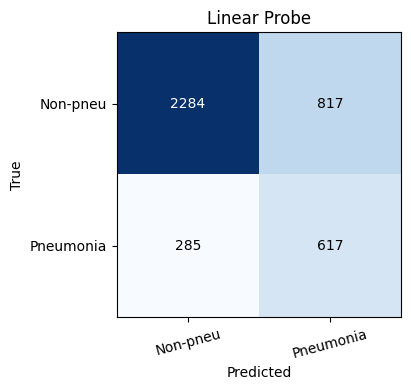

Saved: /kaggle/working/notebook04_ijepa_finetune/figures/cm_linear_probe.png


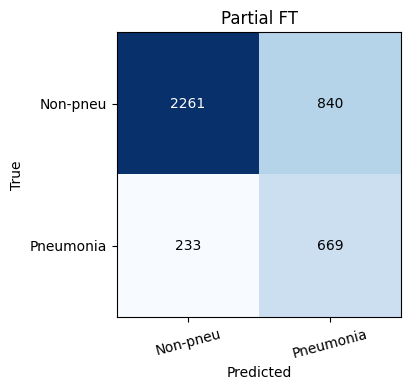

Saved: /kaggle/working/notebook04_ijepa_finetune/figures/cm_partial_ft.png


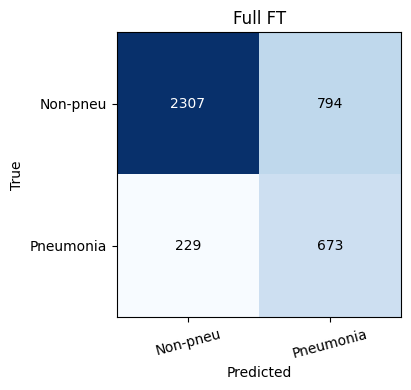

Saved: /kaggle/working/notebook04_ijepa_finetune/figures/cm_full_ft.png


In [34]:
# ============================================================
# CELL 34: CONFUSION MATRICES
# ============================================================

def plot_cm(pred_df, title, save_path):
    y_true = pred_df["label"].astype(int).values
    y_pred = pred_df["pred"].astype(int).values
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Non-pneu","Pneumonia"], rotation=15)
    ax.set_yticklabels(["Non-pneu","Pneumonia"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Saved:", save_path)

plot_cm(linear_pred_df,  "Linear Probe",  FIG_DIR/"cm_linear_probe.png")
plot_cm(partial_pred_df, "Partial FT",    FIG_DIR/"cm_partial_ft.png")
if RUN_FULL_FINETUNE and full_pred_df is not None:
    plot_cm(full_pred_df, "Full FT", FIG_DIR/"cm_full_ft.png")

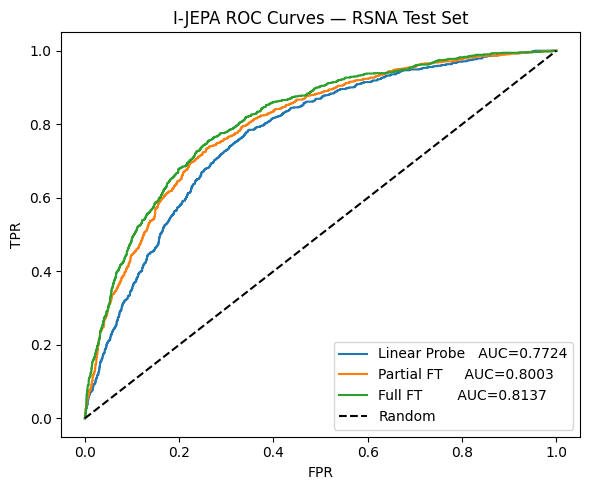

Saved: /kaggle/working/notebook04_ijepa_finetune/figures/ijepa_roc_curves.png


In [35]:
# ============================================================
# CELL 35: ROC CURVES
# ============================================================

from sklearn.metrics import roc_curve

def roc_data(pred_df):
    yt = pred_df["label"].astype(int).values
    yp = pred_df["prob_pneumonia"].values
    return roc_curve(yt, yp) + (roc_auc_score(yt, yp),)

plt.figure(figsize=(6, 5))

fpr, tpr, _, auc = roc_data(linear_pred_df)
plt.plot(fpr, tpr, label=f"Linear Probe   AUC={auc:.4f}")

fpr, tpr, _, auc = roc_data(partial_pred_df)
plt.plot(fpr, tpr, label=f"Partial FT     AUC={auc:.4f}")

if RUN_FULL_FINETUNE and full_pred_df is not None:
    fpr, tpr, _, auc = roc_data(full_pred_df)
    plt.plot(fpr, tpr, label=f"Full FT        AUC={auc:.4f}")

plt.plot([0,1],[0,1], "k--", label="Random")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("I-JEPA ROC Curves — RSNA Test Set")
plt.legend(); plt.tight_layout()
roc_path = FIG_DIR / "ijepa_roc_curves.png"
plt.savefig(roc_path, dpi=150); plt.show()
print("Saved:", roc_path)

In [36]:
# ============================================================
# CELL 36: SO SÁNH NHANH VỚI BASELINE (NẾU CÓ)
# ============================================================

baseline_csv = find_file("baseline_metrics.csv")

if baseline_csv:
    baseline_df = pd.read_csv(baseline_csv)
    compare_df  = pd.concat([baseline_df, ijepa_metrics_df], ignore_index=True)
    compare_df.to_csv(OUTPUT_DIR / "all_models_compare.csv", index=False)
    display(compare_df[["model","auc","f1","recall_pneumonia","specificity"]])
    print("Saved: all_models_compare.csv")
else:
    print("baseline_metrics.csv không tìm thấy — bỏ qua so sánh.")

,model,auc,f1,recall_pneumonia,specificity
0,ResNet50 ImageNet,0.886191,0.624920,0.542129,0.943889
1,ViT-Small/16 ImageNet,0.879745,0.416944,0.278271,0.983554
2,I-JEPA Linear Probe,0.772430,0.528253,0.684035,0.736537
3,I-JEPA Partial FT (4blk),0.800320,0.554956,0.741685,0.729120
4,I-JEPA Full FT,0.813700,0.568172,0.746120,0.743954


Saved: all_models_compare.csv


In [37]:
# ============================================================
# CELL 37: LƯU CONFIG
# ============================================================

config = {
    "seed": SEED, "img_size": IMG_SIZE, "batch_size": BATCH_SIZE,
    "pos_weight": float(POS_WEIGHT.item()),
    "encoder_checkpoint": str(IJEPA_ENCODER_CKPT),
    "backbone": "vit_small_patch16_224",
    "linear":  {"epochs": 15, "lr": 1e-3, "patience": 5, "warmup": 0.10},
    "partial":  {"epochs": 20, "lr_head": 1e-4, "lr_enc": 1e-5,
                  "n_blocks": 4, "patience": 6, "warmup": 0.10},
    "full":     {"epochs": 20, "lr_head": 5e-5, "lr_enc": 5e-6,
                  "weight_decay": 0.05, "patience": 6, "warmup": 0.15},
    "loss": "BCEWithLogitsLoss+pos_weight",
    "optimizer": "AdamW", "scheduler": "cosine+warmup",
}

with open(OUTPUT_DIR / "ijepa_finetune_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Config saved.")

Config saved.


In [38]:
# ============================================================
# CELL 38: NÉN OUTPUT
# ============================================================

print("Files trong output:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.relative_to(OUTPUT_DIR)}  ({size_mb:.1f} MB)")

zip_base = "/kaggle/working/notebook04_ijepa_finetune"
shutil.make_archive(zip_base, "zip", OUTPUT_DIR)
print("Zip created:", zip_base + ".zip")

Files trong output:
  all_models_compare.csv  (0.0 MB)
  checkpoints/ijepa_full_finetune_best.pth  (86.7 MB)
  checkpoints/ijepa_full_finetune_last_epoch_18.pth  (86.7 MB)
  checkpoints/ijepa_full_finetune_last_epoch_19.pth  (86.7 MB)
  checkpoints/ijepa_full_finetune_last_epoch_20.pth  (86.7 MB)
  checkpoints/ijepa_linear_probe_best.pth  (86.7 MB)
  checkpoints/ijepa_linear_probe_last_epoch_13.pth  (86.7 MB)
  checkpoints/ijepa_linear_probe_last_epoch_14.pth  (86.7 MB)
  checkpoints/ijepa_linear_probe_last_epoch_15.pth  (86.7 MB)
  checkpoints/ijepa_partial_finetune_best.pth  (86.7 MB)
  checkpoints/ijepa_partial_finetune_last_epoch_18.pth  (86.7 MB)
  checkpoints/ijepa_partial_finetune_last_epoch_19.pth  (86.7 MB)
  checkpoints/ijepa_partial_finetune_last_epoch_20.pth  (86.7 MB)
  figures/cm_full_ft.png  (0.0 MB)
  figures/cm_linear_probe.png  (0.0 MB)
  figures/cm_partial_ft.png  (0.0 MB)
  figures/ijepa_roc_curves.png  (0.1 MB)
  ijepa_finetune_config.json  (0.0 MB)
  ijepa_finetun